# Data Challenge 7 — Evaluating SLR, Assumptions, & the Bias–Variance Tradeoff

**Goal:** Fit a simple linear regression (SLR) with a **train–test split**, report **MAE/RMSE** on *unseen* data, and use **training residuals** to check assumptions. Explain **bias vs. variance** in plain English.


> Dataset: **NYC Yellow Taxi — Dec 2023** (CSV). Keep code *simple* — minimal coercion for chosen columns only.

## We Do — Instructor Session (20 mins)
Use this **step-by-step plan** to guide students. Keep it high-level; they will implement in the *You Do* section.

**Docs (quick links):**
- Train/Test Split — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- MAE / MSE / RMSE — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
- OLS (fit/predict/residuals) — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html
- OLS Results (attributes like `resid`, `fittedvalues`, `summary`) — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html
- Q–Q plot — SciPy: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html

### Pseudocode Plan
1) **Load CSV** → preview columns/shape.
2) **Assign Y and X (one predictor)** → pick numeric columns that matter; if needed, coerce **just** these to numeric and drop NAs.
3) **Add intercept** → `X = add_constant(X)`.
4) **Train–test split (80/20)** → `X_train, X_test, y_train, y_test = train_test_split(...)` (set `random_state`).
5) **Fit on TRAIN** → `model = OLS(y_train, X_train).fit()`.
6) **Predict on TEST** → `y_pred = model.predict(X_test)`.
7) **Evaluate on TEST** → compute **MAE** and **RMSE** using `y_test` & `y_pred`; speak in **units of Y**.
8) **Diagnostics on TRAIN** → use `model.resid` & `model.fittedvalues` for residuals vs fitted; Q–Q plot; check Durbin–Watson in `model.summary()`.
9) **Bias–variance read (optional)** → compare train vs test errors.
10) **Stakeholder one-liner** → MAE/RMSE in units + brief reliability note.


## You Do — Student Section
Work in pairs. Keep code simple and comment your choices.

### Step 0 — Setup & Imports

In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats


### Step 1 & 2 — Read in the file and Choose **Y** (target) and **X** (one predictor)
- Keep them numeric and present in your CSV.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [31]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures/Mod6/data/2023_Yellow_Taxi_Trip_Data_20251015.csv', low_memory=False)
# converting to numeric
num_cols = ['fare_amount', 'tip_amount', 'trip_distance','total_amount']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
    )
df = df[(df['fare_amount'] > 0) & (df['tip_amount'] >= 0) & (df['trip_distance'] > 0)]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=num_cols)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.0)
    Q3 = df[column].quantile(0.90)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df = remove_outliers_iqr(df, 'fare_amount')
df = remove_outliers_iqr(df, 'trip_distance')
y = df['fare_amount']
X = df['trip_distance']

### Step 3 — Train–Test Split (80/20 random split for practice)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state= 42,
    shuffle= True       
)


### Step 4 — Fit on TRAIN only; Evaluate on TEST
Compute **MAE** and **RMSE** in the **units of Y**.

In [39]:
# Add intercept to X_train and X_test
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Fit the model
model = sm.OLS(y_train, X_train).fit()
y_pred = model.predict(X_test)

# Calculate MAE and RMSE

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: ${test_mae:.2f}")
print(f"RMSE: ${test_rmse:.2f}")


MAE: $3.62
RMSE: $5.76


### Step 5 — Diagnostic Plots (TRAIN residuals)
Check regression assumptions using **training** residuals.
- **Homoscedasticity:** random cloud around 0 (no cone).
- **Normality:** Q–Q plot ~ diagonal.

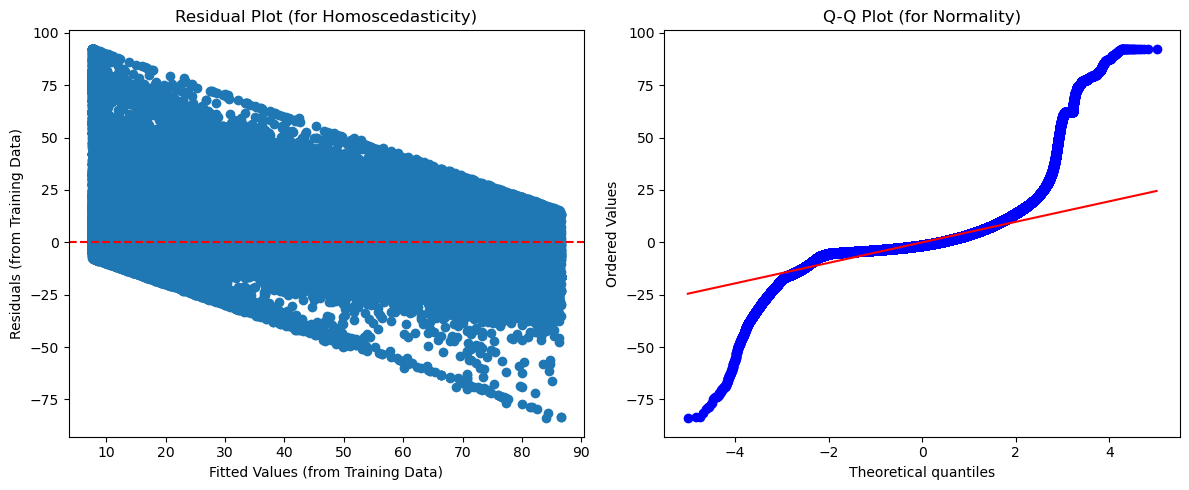

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            fare_amount   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                 1.657e+07
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:37:53   Log-Likelihood:            -8.0640e+06
No. Observations:             2543745   AIC:                         1.613e+07
Df Residuals:                 2543743   BIC:                         1.613e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.5988      0.005   1639.015      0.000       7.590       7.608
trip_distance     3.6715      0.001   4070.740      0.000       3.670       3.673
==============================================================================
Omnibus:                  2222290.982   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        160753638.569
Skew:                           3.875   Prob(JB):                         0.00
Kurtosis:                      41.166   Cond. No.                         6.70
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [36]:
residuals = model.resid
fitted = model.fittedvalues
# 1. Plot for Homoscedasticity
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (for Homoscedasticity)')
plt.xlabel('Fitted Values (from Training Data)')
plt.ylabel('Residuals (from Training Data)')

# 2. Q-Q Plot for Normality
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot (for Normality)')

plt.tight_layout()
plt.show()
model.summary()

### Step 6 — Quick Bias–Variance Read (optional)
Compare **train** and **test** errors and describe what you see.

In [44]:
# finding the errors for trained
y_train_pred = model.predict(X_train)

# Test errors
trained_mae = mean_absolute_error(y_train, y_train_pred)
trained_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

print("Train MAE:", trained_mae)
print("Test MAE:", test_mae)
print("Train RMSE:", trained_rmse)
print("Test RMSE:", test_rmse)


## How relative is the errors to y variable, we will use the mean unseen data Y_test
mean_y = y_test.mean()
error_rate_mae = test_mae / mean_y
error_rate_rmse = test_rmse / mean_y
print(f'mae_rate = {error_rate_mae * 100}%')
print(f'rmse_rate = {error_rate_rmse * 100}%')

Train MAE: 3.6162311088798313
Test MAE: 3.6177770990183964
Train RMSE: 5.761418140803297
Test RMSE: 5.763995043282026
mae_rate = 18.600218829618733%
rmse_rate = 29.634653048960057%


Train error and test error are almost equals, we can say that the model has a balanced Bias-variance, it generalizes well as the error on the train data are approximately same for the test data

## We Share — Reflection & Wrap‑Up
Write **1–2 short paragraphs** addressing:


1) **Is this model good enough** for a real decision **right now**? Why/why not?
Refer to **MAE/RMSE in units**, any **assumption issues**, and whether accuracy meets a reasonable business threshold.

with a Mean Absolute Error of $3.61, which is 18.6 % relative to the average of fare_amount, we can say that our model's prediction is off by about 19% on average, which is a moderate error rate. Evaluating the model on our test data shows that the model generalizes well as the error seen on train is approximately the same on test data. In summary, the model predicts fare amount based on trip distance with a mean absolute error of 18% in average.


2) **What’s your next move** to improve trust/accuracy?
Examples: adopt a **time‑aware split**, try a more relevant **X**, transform variables, segment checks (hour/zone), or move to **Multiple Linear Regression** with validation.
THe model power is over 85%, which is a strong indicator that the trip distance feature explains much of the variation seen by the data. however, we can still improve the model accuracy by reducing errors, by transforming and segmenting trip distance to catch more patterns, or by adding another feature on top of trip_distance such as time of pick up, which could be a strong factor on predicting fare_amount.